## **3. Multi-scale patch processing - Transfer Learning + Fine Tuning**


In this notebook the goal is to process in parallel **3 differently zoomed patches of the same mask region**, in order to provide more context to the feature extraction network. The training set is built of 3 collections of patches; each unique patch, extracted from the original WSI images, appears in the collections with 3 different scales (5x, 10x and 20x centered zoom), which are all resized to 100x100. The model, trained both with transfer learning and fine tuning, consists of **3 parallel ConvNext-Tiny FEN backbones** that process each patch version independently, generating 3 distinct feature representations; these are then concatenated (to generate the overall patch latent representation) and fed to an MPL classifier. WSI-level predictions are generated by averaging patch-level softmax probabilities per WSI.

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challenge2AN2DL"
%cd $current_dir

## ⚙️ **Libraries Import and Parameter Setting**

In [ ]:
!pip install torch torchvision scikit-learn pandas

import os
import random
import pickle
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as F
from torchvision.models import (
    efficientnet_b3, EfficientNet_B3_Weights,
    resnet18, ResNet18_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights
)

In [ ]:
# Define file paths

DATA_ROOT = "multires_baseline"

# train_data_dictionary = { "img_XXXX.png" : (H,W,3) }, where:
#   - XXXX is the zero-padded patch index
#   - (H,W,3) is a 3D matrix describing the patch
#   - pixel values between 0 and 255

# Patches with 5x zoom
PICKLE_5X_PATH  = os.path.join(DATA_ROOT, "train_data_dictionary_5x_100.pkl")
# Patches with 10x zoom
PICKLE_10X_PATH = os.path.join(DATA_ROOT, "train_data_dictionary_10x_100.pkl")
# Patches with 20x zoom
PICKLE_20X_PATH = os.path.join(DATA_ROOT, "train_data_dictionary_20x_100.pkl")

# "cleaned_patched_train_labels.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "label" -> label of the WSI from which the patch was extracted
#   - "original_idx" -> index of the WSI from which the patch was extracted

CSV_PATH        = os.path.join(DATA_ROOT, "cleaned_patched_train_labels.csv")

In [ ]:
# Seed for reproducibility

SEED = 34343
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## ⏳ **Data Loading**

In [ ]:
# Load the dictionaries describing the multi-scale patches

with open(PICKLE_5X_PATH, "rb") as f:
    data_5x = pickle.load(f)

with open(PICKLE_10X_PATH, "rb") as f:
    data_10x = pickle.load(f)

with open(PICKLE_20X_PATH, "rb") as f:
    data_20x = pickle.load(f)

# Load the csv file

df = pd.read_csv(CSV_PATH)

print("First rows of the CSV:")
print(df.head())

First rows of the CSV:
   index            label  original_idx
0      1  Triple negative             0
1      2  Triple negative             0
2      3  Triple negative             0
3      4  Triple negative             0
4      5  Triple negative             0


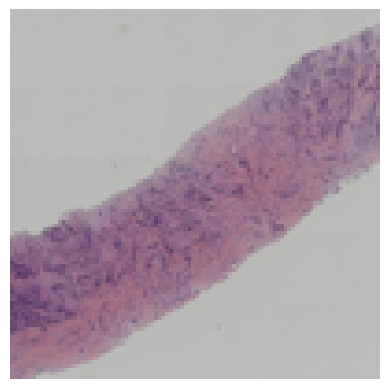

In [ ]:
# Example of training patch
plt.imshow((data_20x["img_1342.png"]).astype(np.uint8))
plt.axis('off')
plt.show()

In [ ]:
# Transform patch IDs into png file names
df['patch_name'] = df['index'].apply(lambda x: f"img_{int(x):04d}.png")

# Patch name consistency check
def check_key(k):
    return (k in data_5x) and (k in data_10x) and (k in data_20x)

df = df[df["patch_name"].apply(check_key)].reset_index(drop=True)
print(f"Number of patches: {len(df)}")

Number of patches: 5014


In [ ]:
# Label encoding
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"].values)

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_, " -> num_classes =", num_classes)

Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']  -> num_classes = 4


##  📄 **Data Preprocessing**

In [ ]:
WSI_COL = "original_idx"

# Random shuffle of unique WSI indices
unique_wsis = df[WSI_COL].unique()
np.random.shuffle(unique_wsis)

# 80-20 training-validation splitting per WSI, no data leakage (patched extracted from the same WSI will be in the same set)
n_train_wsis = int(0.8 * len(unique_wsis))
train_wsis = set(unique_wsis[:n_train_wsis])
val_wsis   = set(unique_wsis[n_train_wsis:])

def split_from_wsi(orig_idx):
    return "train" if orig_idx in train_wsis else "val"

df["split"] = df[WSI_COL].apply(split_from_wsi)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "val"].reset_index(drop=True)

# Define weights for cross-entropy loss
class_counts = df_train["label_encoded"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

print(f"Number of WSIs: {len(unique_wsis)}, train WSI: {len(train_wsis)}, val WSI: {len(val_wsis)}")
print(f"Patch train: {len(df_train)}, Patch val: {len(df_val)}")
print("Class counts:", class_counts)
print("Class weights:", class_weights)

Number of WSIs: 581, train WSI: 464, val WSI: 117
Patch train: 3974, Patch val: 1040
Class counts: [1124 1072 1394  384]
Class weights: [0.69181368 0.72537181 0.55781821 2.0249963 ]


In [ ]:
class MultiScalePatchDataset(Dataset):
    """Custom PyTorch Dataset with optional augmentation and normalization."""
    def __init__(self, df, dict_5x, dict_10x, dict_20x, augment=False):
        """
        Args:
            df: dataset that associates to each patch the label and index of the corresponding WSI
            dict_5x: dictionary containing the patches with 5x zoom
            dict_10x: dictionary containing the patches with 10x zoom
            dict_20x: dictionary containing the patches with 20x zoom
            augment: transforms for data augmentation
        """
        self.df = df
        self.dict_5x = dict_5x
        self.dict_10x = dict_10x
        self.dict_20x = dict_20x
        self.augment = augment

        # Imagenet normalization statistics
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.df)

    def _to_tensor(self, img_np):
        # img_np: (H, W, 3) float32 [0,255]
        img = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0   # (3, H, W) float32 [0,1]
        # 224x224 resize
        img = F.resize(img, [224, 224])
        # Normalization
        img = (img - self.mean) / self.std
        return img

    # This function applies the SAME augmentation to the 3 scaled versions of the same patch
    def _apply_same_augmentation(self, img5, img10, img20):
        # Random flipping
        if random.random() < 0.5:
            img5  = F.hflip(img5)
            img10 = F.hflip(img10)
            img20 = F.hflip(img20)
        if random.random() < 0.5:
            img5  = F.vflip(img5)
            img10 = F.vflip(img10)
            img20 = F.vflip(img20)

        # Random rotation
        k = random.randint(0, 3)
        if k > 0:
            img5  = torch.rot90(img5,  k, [1, 2])
            img10 = torch.rot90(img10, k, [1, 2])
            img20 = torch.rot90(img20, k, [1, 2])

        return img5, img10, img20

    # This function accesses to the dictionaries to return the 3 scaled versions of a patch, together with the associated label
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_name = row["patch_name"]
        label = int(row["label_encoded"])

        img5_np  = self.dict_5x[patch_name].astype(np.float32)
        img10_np = self.dict_10x[patch_name].astype(np.float32)
        img20_np = self.dict_20x[patch_name].astype(np.float32)

        img5  = self._to_tensor(img5_np)
        img10 = self._to_tensor(img10_np)
        img20 = self._to_tensor(img20_np)

        if self.augment:
            img5, img10, img20 = self._apply_same_augmentation(img5, img10, img20)

        return img5, img10, img20, label

In [ ]:
# Define batch size
BATCH_SIZE = 16

In [ ]:
# Create datasets
train_dataset = MultiScalePatchDataset(df_train, data_5x, data_10x, data_20x, augment=True)
val_dataset   = MultiScalePatchDataset(df_val,   data_5x, data_10x, data_20x, augment=False)

# Create data loaders for training and validation sets
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

##  🧮 **Network Parameters**

In [ ]:
# Transfer learning parameters
MLP_LEARNING_RATE = 5e-5
FEN_LEARNING_RATE = 1e-5

# Fine tuning parameters
UNFREEZE_LAYERS = 1
FEN_LEARNING_RATE_FT = FEN_LEARNING_RATE * 0.1
MLP_LEARNING_RATE_FT = MLP_LEARNING_RATE * 0.1

# Optimizer parameters
L2_LAMBDA = 1e-2
SMOOTHING_FACTOR = 0.1

# Training setting
MAX_EPOCHS = 200
PATIENCE   = 20

## 🧠 **Model Training**

In [ ]:
# This function runs the model for one epoch on the training or validation set (depending on the optimizer parameter)

def run_epoch(model, loader, optimizer=None):
    # Decide if training or validation
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    torch.set_grad_enabled(is_train)

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for img5, img10, img20, labels in loader:
        img5   = img5.to(device, non_blocking=True)
        img10  = img10.to(device, non_blocking=True)
        img20  = img20.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        logits = model(img5, img10, img20)
        loss = criterion(logits, labels)

        if is_train:
            # If training, perform backward pass
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        # Loss function update
        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")
    return avg_loss, weighted_f1

In [ ]:
def fit(model, train_loader, val_loader, optimizer, epochs, patience):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": []
    }

    # Initialize best model tracking variables
    best_f1 = -np.inf
    best_epoch = -1
    best_state_dict = None

    # Training and validation loop
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss,   val_f1   = run_epoch(model, val_loader,   optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch:03d} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train wF1: {train_f1:.4f} | Val wF1: {val_f1:.4f}")

        # Early stopping wrt validation F1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
        else:
            if epoch - best_epoch >= patience:
                print(f"Early stopping triggered at epoch {epoch} (best epoch: {best_epoch})")
                break

    print("Best epoch:", best_epoch, "with F1:", best_f1)
    return best_state_dict, history


## 🛠️ **Transfer Learning**

In [ ]:
import torchvision

# The model consists of 3 parallel FEN ConvNeXt-Tiny backbones that extract features from the 3 different scaled versions of each patch;
#     the features are then concatenated to generate the final latent representation for the patch, which is finally processed by a MPL classifier

class MultiScaleNet(nn.Module):
    def __init__(self, num_classes=4, unfreeze_last_k=0):
        super().__init__()

        mob_weights = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT

        #-------------------------------
        # Backbone FEN 1: 5x zoomed patches
        #-------------------------------
        self.backbone1 = torchvision.models.convnext_tiny(weights=mob_weights)
        mob_feat_dim = self.backbone1.classifier[-1].in_features
        self.backbone1.classifier[-1] = nn.Identity()

        #-------------------------------
        # Backbone FEN 2: 10x zoomed patches
        #-------------------------------
        self.backbone2 = torchvision.models.convnext_tiny(weights=mob_weights)
        self.backbone2.classifier[-1] = nn.Identity()

        #-------------------------------
        # Backbone FEN 3: 20x zoomed patches
        #-------------------------------
        self.backbone3 = torchvision.models.convnext_tiny(weights=mob_weights)
        self.backbone3.classifier[-1] = nn.Identity()

        # Freeze backbones completely
        for b in [self.backbone1, self.backbone2, self.backbone3]:
            for p in b.parameters():
                p.requires_grad = False

        # Unfreeze last k layers
        if unfreeze_last_k > 0:
            num_blocks = len(self.backbone1.features)
            k = min(unfreeze_last_k, num_blocks)
            for b in [self.backbone1, self.backbone2, self.backbone3]:
                for i in range(num_blocks - k, num_blocks):
                    for p in b.features[i].parameters():
                        p.requires_grad = True

        # MLP classifier
        self.mlp = nn.Sequential(
            nn.Linear(mob_feat_dim * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x5, x10, x20):
        f1 = self.backbone1(x5)   # [B, mob_feat_dim]
        f2 = self.backbone2(x10)  # [B, mob_feat_dim]
        f3 = self.backbone3(x20)  # [B, mob_feat_dim]

        # The features generated by the parallel backbones are concatenated
        feats = torch.cat([f1, f2, f3], dim=1)  # [B, mob_feat_dim * 3]
        logits = self.mlp(feats)                # [B, num_classes]
        return logits


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model for transfer learning
model = MultiScaleNet(num_classes=4, unfreeze_last_k=0).to(device)

# Define weighted cross-entropy loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=SMOOTHING_FACTOR
)

backbone_params = []
mlp_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(p)
    else:
        mlp_params.append(p)

# Optimizer
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": FEN_LEARNING_RATE},  # Lower learning rate for the FEN backbones
        {"params": mlp_params,      "lr": MLP_LEARNING_RATE},  # Higher learning rate for the MLP
    ],
    weight_decay=L2_LAMBDA,
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [ ]:
# Transfer learning process
best_state_dict, history = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    MAX_EPOCHS,
    PATIENCE
)

# Save best model
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

Epoch 001 | Train Loss: 1.4006 | Val Loss: 1.3804 | Train wF1: 0.3094 | Val wF1: 0.3771
Epoch 002 | Train Loss: 1.3580 | Val Loss: 1.3747 | Train wF1: 0.3653 | Val wF1: 0.2840
Epoch 003 | Train Loss: 1.3224 | Val Loss: 1.3541 | Train wF1: 0.4082 | Val wF1: 0.3751
Epoch 004 | Train Loss: 1.2986 | Val Loss: 1.3447 | Train wF1: 0.4233 | Val wF1: 0.3999
Epoch 005 | Train Loss: 1.2776 | Val Loss: 1.3580 | Train wF1: 0.4442 | Val wF1: 0.3740
Epoch 006 | Train Loss: 1.2568 | Val Loss: 1.3433 | Train wF1: 0.4688 | Val wF1: 0.4154
Epoch 007 | Train Loss: 1.2369 | Val Loss: 1.3527 | Train wF1: 0.4807 | Val wF1: 0.3731
Epoch 008 | Train Loss: 1.2159 | Val Loss: 1.3608 | Train wF1: 0.5008 | Val wF1: 0.3739
Epoch 009 | Train Loss: 1.2041 | Val Loss: 1.3546 | Train wF1: 0.5187 | Val wF1: 0.4156
Epoch 010 | Train Loss: 1.1871 | Val Loss: 1.3511 | Train wF1: 0.5152 | Val wF1: 0.4304
Epoch 011 | Train Loss: 1.1747 | Val Loss: 1.3571 | Train wF1: 0.5413 | Val wF1: 0.4012
Epoch 012 | Train Loss: 1.1520 |

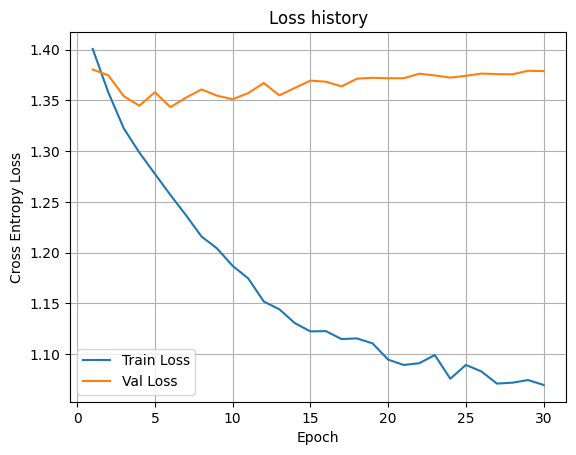

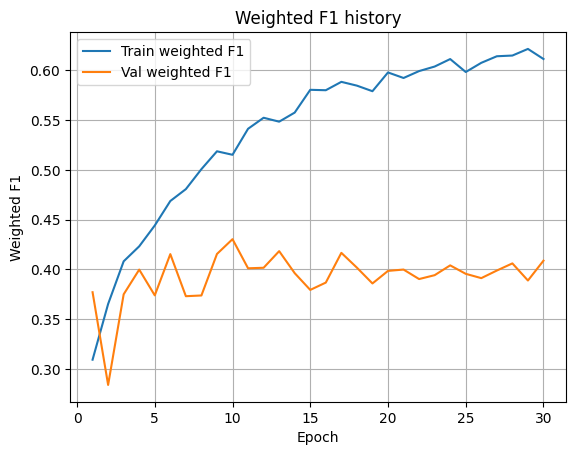

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
epochs_range = range(1, len(history["train_loss"]) + 1)

# Plot of training and validation loss on the first axis
plt.figure()
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.title("Loss history")
plt.grid(True)
plt.show()

# Plot of training and validation F1 on the second axis
plt.figure()
plt.plot(epochs_range, history["train_f1"], label="Train weighted F1")
plt.plot(epochs_range, history["val_f1"],   label="Val weighted F1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.legend()
plt.title("Weighted F1 history")
plt.grid(True)
plt.show()

## 🛠️ **Fine Tuning**

In [ ]:
# Create a new model with the last backbone layers unfreezed
model_ft = MultiScaleNet(num_classes=4, unfreeze_last_k=UNFREEZE_LAYERS).to(device)

# Load the weights of the previously trained model
model_ft.load_state_dict(best_state_dict)

backbone_params = []
mlp_params = []

for name, p in model_ft.named_parameters():
    if not p.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(p)
    else:
        mlp_params.append(p)

# Optimizer
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": FEN_LEARNING_RATE_FT},
        {"params": mlp_params,      "lr": MLP_LEARNING_RATE_FT},
    ],
    weight_decay=L2_LAMBDA,
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)


In [ ]:
# Fine tuning process
best_state_dict_ft, history_ft = fit(
    model_ft,
    train_loader,
    val_loader,
    optimizer,
    MAX_EPOCHS,
    PATIENCE
)

if best_state_dict_ft is not None:
    model_ft.load_state_dict(best_state_dict_ft)

Epoch 001 | Train Loss: 1.1662 | Val Loss: 1.3570 | Train wF1: 0.5517 | Val wF1: 0.3949
Epoch 002 | Train Loss: 1.1609 | Val Loss: 1.3555 | Train wF1: 0.5429 | Val wF1: 0.3933
Epoch 003 | Train Loss: 1.1552 | Val Loss: 1.3591 | Train wF1: 0.5536 | Val wF1: 0.3932
Epoch 004 | Train Loss: 1.1477 | Val Loss: 1.3587 | Train wF1: 0.5534 | Val wF1: 0.4133
Epoch 005 | Train Loss: 1.1374 | Val Loss: 1.3583 | Train wF1: 0.5643 | Val wF1: 0.4016
Epoch 006 | Train Loss: 1.1339 | Val Loss: 1.3586 | Train wF1: 0.5555 | Val wF1: 0.3997
Epoch 007 | Train Loss: 1.1286 | Val Loss: 1.3609 | Train wF1: 0.5694 | Val wF1: 0.3992
Epoch 008 | Train Loss: 1.1279 | Val Loss: 1.3615 | Train wF1: 0.5688 | Val wF1: 0.4057
Epoch 009 | Train Loss: 1.1222 | Val Loss: 1.3624 | Train wF1: 0.5719 | Val wF1: 0.4087
Epoch 010 | Train Loss: 1.1320 | Val Loss: 1.3623 | Train wF1: 0.5667 | Val wF1: 0.4050
Epoch 011 | Train Loss: 1.1174 | Val Loss: 1.3635 | Train wF1: 0.5783 | Val wF1: 0.4067
Epoch 012 | Train Loss: 1.1119 |

## 🧠 **Inference**

In [ ]:
# Define file paths

DATA_ROOT = "multires_baseline"

# train_data_dictionary = { "img_XXXX.png" : (H,W,3) }, where:
#   - XXXX is the zero-padded patch index
#   - (H,W,3) is a 3D matrix describing the patch
#   - pixel values between 0 and 255

# Patches with 5x zoom
PICKLE_5X_TEST_PATH  = os.path.join(DATA_ROOT, "test_data_dictionary_5x_100.pkl")
# Patches with 10x zoom
PICKLE_10X_TEST_PATH = os.path.join(DATA_ROOT, "test_data_dictionary_10x_100.pkl")
# Patches with 20x zoom
PICKLE_20X_TEST_PATH = os.path.join(DATA_ROOT, "test_data_dictionary_20x_100.pkl")

# "test.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "original_idx" -> index of the WSI from which the patch was extracted
TEST_CSV_PATH = os.path.join(DATA_ROOT, "test.csv")

In [ ]:
# Load the dictionaries describing the multi-scale patches

with open(PICKLE_5X_TEST_PATH, "rb") as f:
    test_data_5x = pickle.load(f)

with open(PICKLE_10X_TEST_PATH, "rb") as f:
    test_data_10x = pickle.load(f)

with open(PICKLE_20X_TEST_PATH, "rb") as f:
    test_data_20x = pickle.load(f)

# Load the csv file

df_test = pd.read_csv(TEST_CSV_PATH)

# Rename dataframe column
df_test["patch_name"] = df_test["index"].apply(lambda x: f"img_{int(x):04d}.png")

# Consistency check
def check_key(k):
    return (k in test_data_5x) and (k in test_data_10x) and (k in test_data_20x)

df_test = df_test[df_test["patch_name"].apply(check_key)].reset_index(drop=True)
print("Test patches disponibili:", len(df_test))
print(df_test.head())

Test patches disponibili: 3909
   index  original_idx    patch_name
0      1             0  img_0001.png
1      2             0  img_0002.png
2      3             0  img_0003.png
3      4             0  img_0004.png
4      5             1  img_0005.png


In [ ]:
class MultiScalePatchDatasetTest(Dataset):
    """Custom PyTorch Dataset for test set."""
    def __init__(self, df, dict_5x, dict_10x, dict_20x):
        """
        Args:
            df: dataset that associates to each patch the index of the corresponding WSI
            dict_5x: dictionary containing the patches with 5x zoom
            dict_10x: dictionary containing the patches with 10x zoom
            dict_20x: dictionary containing the patches with 20x zoom
        """
        self.df = df
        self.dict_5x = dict_5x
        self.dict_10x = dict_10x
        self.dict_20x = dict_20x

        # Imagenet normalization statistics
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.df)

    def _to_tensor(self, img_np):
        # img_np: (H, W, 3) float32 [0,255]
        img = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        # 224x224 resize
        img = F.resize(img, [224, 224])
        # Normalization
        img = (img - self.mean) / self.std
        return img

    # This function accesses to the dictionaries to return the 3 scaled versions of a patch, together with the WSI index
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patch_name = row["patch_name"]
        wsi_id = int(row["original_idx"])

        img5_np  = self.dict_5x[patch_name].astype(np.float32)
        img10_np = self.dict_10x[patch_name].astype(np.float32)
        img20_np = self.dict_20x[patch_name].astype(np.float32)

        img5  = self._to_tensor(img5_np)
        img10 = self._to_tensor(img10_np)
        img20 = self._to_tensor(img20_np)

        return img5, img10, img20, wsi_id


In [ ]:
# Define batch size
BATCH_SIZE = 16

In [ ]:
# Create data loader for test set
test_dataset = MultiScalePatchDatasetTest(df_test, test_data_5x, test_data_10x, test_data_20x)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use fine tuning model
inference_model = model_ft.to(device)
inference_model.eval()

sum_probs = defaultdict(lambda: np.zeros(num_classes, dtype=np.float64))
count = defaultdict(int)

# Perform inference on the test patches and save the softmax probabilities
with torch.no_grad():
    for img5, img10, img20, wsi_id in test_loader:
        img5  = img5.to(device, non_blocking=True)
        img10 = img10.to(device, non_blocking=True)
        img20 = img20.to(device, non_blocking=True)

        logits = inference_model(img5, img10, img20)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        wsi_id = wsi_id.cpu().numpy()

        for p, w in zip(probs, wsi_id):
            w = int(w)
            sum_probs[w] += p
            count[w] += 1

In [ ]:
# Compute WSI-level predictions

rows = []
for wsi in sorted(sum_probs.keys()):
    # We average softmax probabilities across patches of the same WSI
    mean_prob = sum_probs[wsi] / max(count[wsi], 1)
    pred_class = int(np.argmax(mean_prob))

    # We perform inverse label mapping
    if "label_encoder" in globals() and label_encoder is not None:
        pred_label = label_encoder.inverse_transform([pred_class])[0]
    else:
        pred_label = pred_class

    row = {
        "original_idx": wsi,
        "n_patches": count[wsi],
        "pred_class": pred_class,
        "pred_label": pred_label,
    }
    for c in range(num_classes):
        row[f"prob_class_{c}"] = float(mean_prob[c])
    rows.append(row)

df_wsi_pred = pd.DataFrame(rows).sort_values("original_idx").reset_index(drop=True)

# Submission csv generation
df_submission = pd.DataFrame({
    "sample_index": df_wsi_pred["original_idx"].apply(lambda x: f"img_{int(x):04d}.png"),
    "label": df_wsi_pred["pred_label"]
})

df_submission.to_csv("submissions/multiscale_ConvNext_submission.csv", index=False)
print(df_submission.head())

   sample_index            label
0  img_0000.png        Luminal A
1  img_0001.png        Luminal B
2  img_0002.png        Luminal A
3  img_0003.png  Triple negative
4  img_0004.png        Luminal B
